In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")

plt.style.use("default")
sns.set_palette("husl")

In [23]:
df = pd.read_csv("data/HousingPrices-Amsterdam-August-2021.csv", index_col=0)
df.head()

,Address,Zip,Price,Area,Room,Lon,Lat
1,"Blasiusstraat 8 2, Amsterdam",1091 CR,685000.0,64,3,4.907736,52.356157
2,"Kromme Leimuidenstraat 13 H, Amsterdam",1059 EL,475000.0,60,3,4.850476,52.348586
3,"Zaaiersweg 11 A, Amsterdam",1097 SM,850000.0,109,4,4.944774,52.343782
4,"Tenerifestraat 40, Amsterdam",1060 TH,580000.0,128,6,4.789928,52.343712
5,"Winterjanpad 21, Amsterdam",1036 KN,720000.0,138,5,4.902503,52.410538


# EDA

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 924 entries, 1 to 924
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Address  924 non-null    object 
 1   Zip      924 non-null    object 
 2   Price    920 non-null    float64
 3   Area     924 non-null    int64  
 4   Room     924 non-null    int64  
 5   Lon      924 non-null    float64
 6   Lat      924 non-null    float64
dtypes: float64(3), int64(2), object(2)
memory usage: 57.8+ KB


In [25]:
df.describe()

,Price,Area,Room,Lon,Lat
count,9.200000e+02,924.000000,924.000000,924.000000,924.000000
mean,6.220654e+05,95.952381,3.571429,4.888605,52.363326
std,5.389942e+05,57.447436,1.592332,0.053140,0.024028
min,1.750000e+05,21.000000,1.000000,4.644819,52.291519
25%,3.500000e+05,60.750000,3.000000,4.855834,52.352077
50%,4.670000e+05,83.000000,3.000000,4.886818,52.364631
75%,7.000000e+05,113.000000,4.000000,4.922337,52.377598
max,5.950000e+06,623.000000,14.000000,5.029122,52.423805


In [26]:
# missing values
df.isnull().sum()

Address    0
Zip        0
Price      4
Area       0
Room       0
Lon        0
Lat        0
dtype: int64

There are almost no missing values in the dataset. We can remove the 4 rows where the prices are missing as it's not so much and the column price is really important and we don't want to have biased values there.

In [27]:
df = df.dropna(subset=["Price"]).copy()
df.isnull().sum().sum()

0

## Univariate Analysis

### Numerical Variables Analysis

In [28]:
# Central tendency measures for numerical variables
numerical_cols = ["Price", "Area", "Room"]


for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean()}")
    print(f"  Median: {df[col].median()}")
    print(f"  Mode: {df[col].mode().iloc[0] if len(df[col].mode()) > 0 else 'No mode'}")

for col in numerical_cols:
    print(f"\n{col}:")
    print(f"  Standard Deviation: {df[col].std()}")
    print(f"  Variance: {df[col].var()}")
    print(f"  Range: {df[col].max() - df[col].min()}")
    print(f"  IQR: {df[col].quantile(0.75) - df[col].quantile(0.25)}")
    print(f"  Skewness: {df[col].skew()}")
    print(f"  Kurtosis: {df[col].kurtosis()}")


Price:
  Mean: 622065.4195652173
  Median: 467000.0
  Mode: 375000.0

Area:
  Mean: 95.60760869565217
  Median: 83.0
  Mode: 78

Room:
  Mean: 3.5641304347826086
  Median: 3.0
  Mode: 3

Price:
  Standard Deviation: 538994.1753643245
  Variance: 290514721076.66815
  Range: 5775000.0
  IQR: 350000.0
  Skewness: 4.828817373245921
  Kurtosis: 33.90564346612449

Area:
  Standard Deviation: 56.849699198451695
  Variance: 3231.8882989544395
  Range: 602
  IQR: 53.0
  Skewness: 3.159772181056663
  Kurtosis: 17.507034037171206

Room:
  Standard Deviation: 1.5710299998547996
  Variance: 2.4681352604437716
  Range: 13
  IQR: 1.0
  Skewness: 1.9729289435839117
  Kurtosis: 7.591538718794837


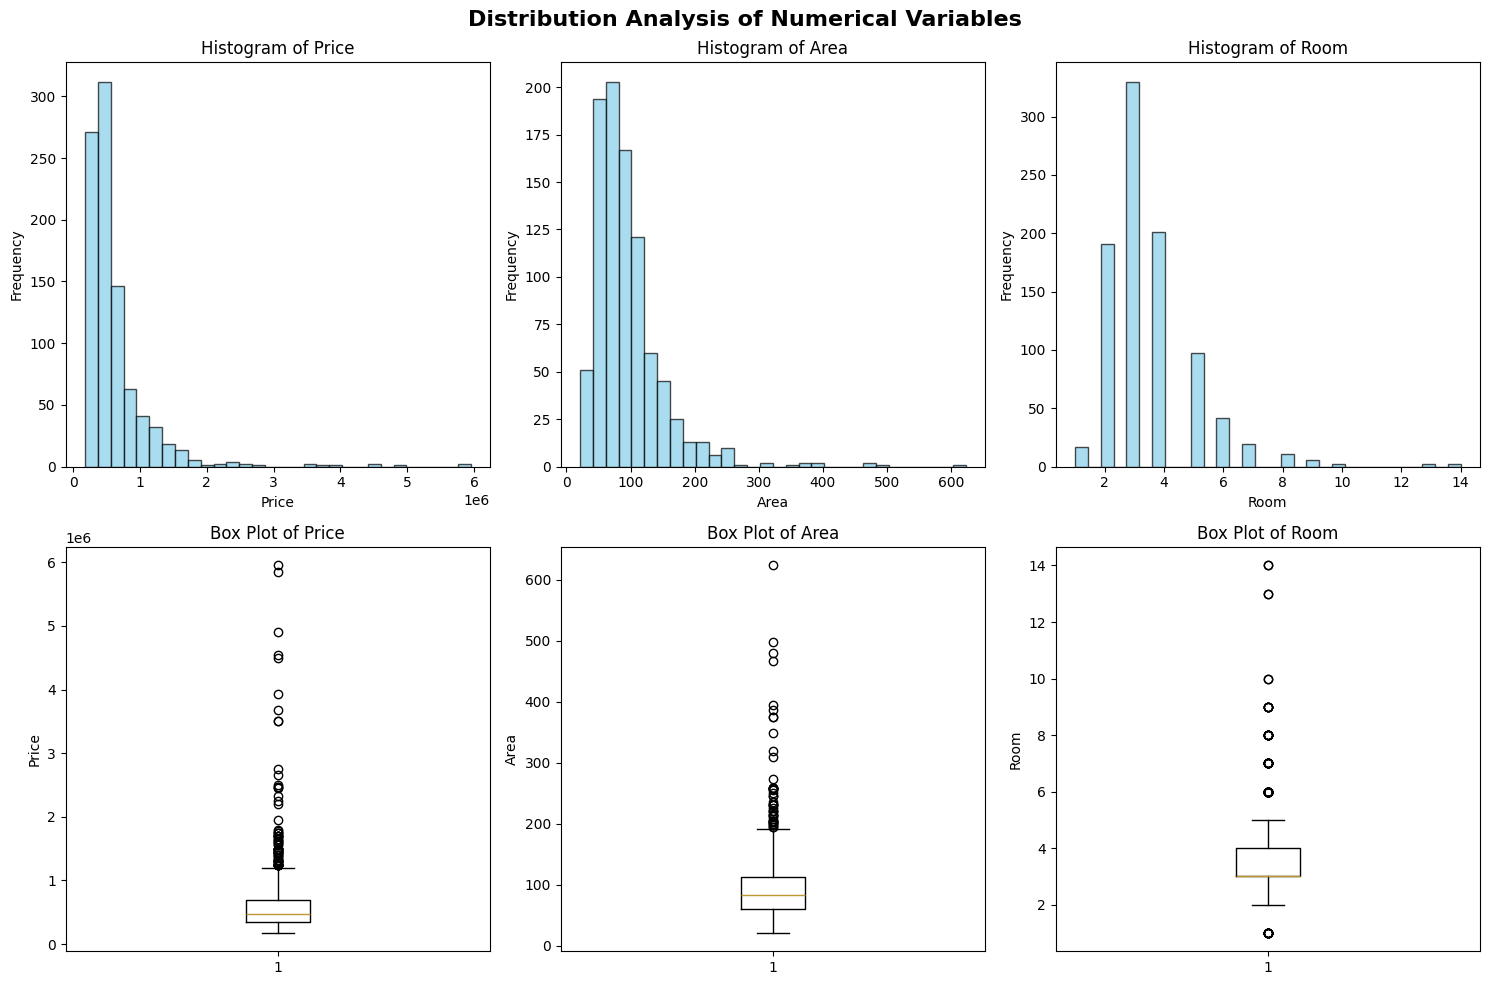

In [29]:
# Distribution visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Distribution Analysis of Numerical Variables", fontsize=16, fontweight="bold")

for i, col in enumerate(numerical_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=30, alpha=0.7, color="skyblue", edgecolor="black")
    axes[0, i].set_title(f"Histogram of {col}")
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel("Frequency")

    # Box plot
    axes[1, i].boxplot(df[col])
    axes[1, i].set_title(f"Box Plot of {col}")
    axes[1, i].set_ylabel(col)

plt.tight_layout()
plt.show()

The distributions are right-skewed and there are outliers in numerical columns

In [30]:
# Outliers - IQR method
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    print(f"\n{col}:")
    print(f"Lower bound: {lower_bound}")
    print(f"Upper bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


Price:
Lower bound: -175000.0
Upper bound: 1225000.0
Number of outliers: 71

Area:
Lower bound: -19.5
Upper bound: 192.5
Number of outliers: 46

Room:
Lower bound: 1.5
Upper bound: 5.5
Number of outliers: 101


### Categorical Variables Analysis

In [31]:
df["Address"].sample(10)

499               Pieter Calandlaan 379, Amsterdam
622       Bloys van Treslongstraat 62 H, Amsterdam
750                 Koninginneweg 195 2, Amsterdam
509    Gillis van Ledenberchstraat 3 HS, Amsterdam
205          Jan van Riebeekstraat 17 3, Amsterdam
404                Stoutenburggracht 11, Amsterdam
751              Van Speijkstraat 175 2, Amsterdam
339                  Westerdoksdijk 375, Amsterdam
344                       Amsteldijk 64, Amsterdam
647             Van Hilligaertstraat 47, Amsterdam
Name: Address, dtype: object

## Multivariate Analysis

### Correlation Analysis (Numerical vs Numerical)

          Price      Area      Room
Price  1.000000  0.835090  0.623448
Area   0.835090  1.000000  0.808285
Room   0.623448  0.808285  1.000000


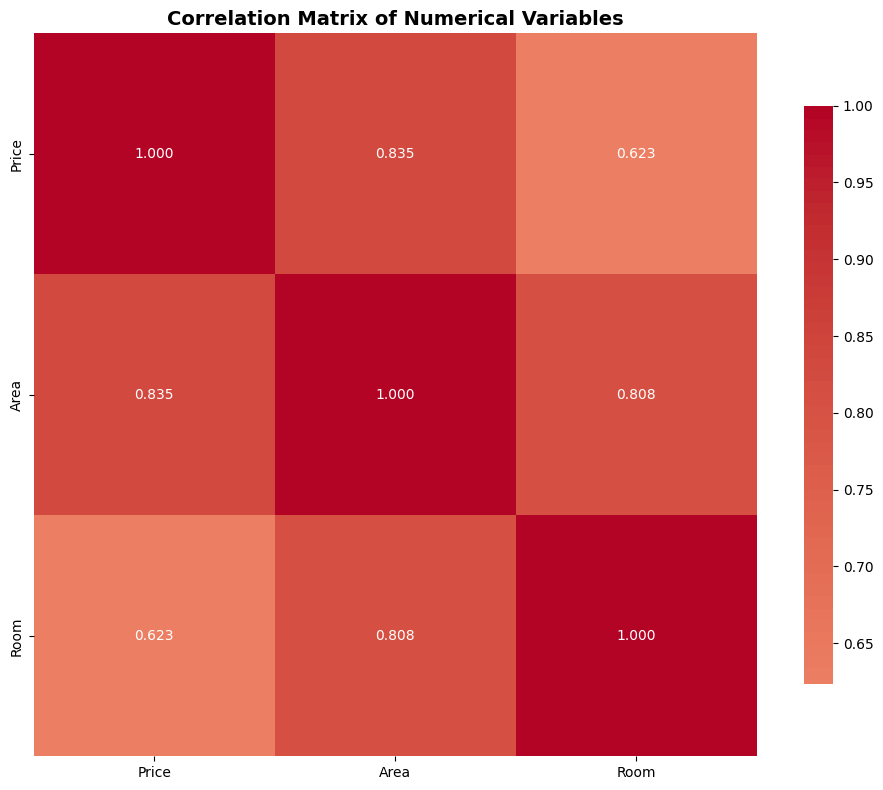

Price vs Area: 0.835
  Interpretation: Strong positive correlation
Price vs Room: 0.623
  Interpretation: Moderate positive correlation


In [35]:
# Correlation matrix for numerical variables
correlation_matrix = df[numerical_cols].corr()


print(correlation_matrix)

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    square=True,
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Matrix of Numerical Variables", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("=" * 30)
for col in ["Area", "Room"]:
    corr_coef = df["Price"].corr(df[col])
    print(f"Price vs {col}: {corr_coef:.3f}")

    # Interpretation
    if abs(corr_coef) > 0.7:
        strength = "Strong"
    elif abs(corr_coef) > 0.5:
        strength = "Moderate"
    elif abs(corr_coef) > 0.3:
        strength = "Weak"
    else:
        strength = "Very weak"

    direction = "positive" if corr_coef > 0 else "negative"
    print(f"  Interpretation: {strength} {direction} correlation")

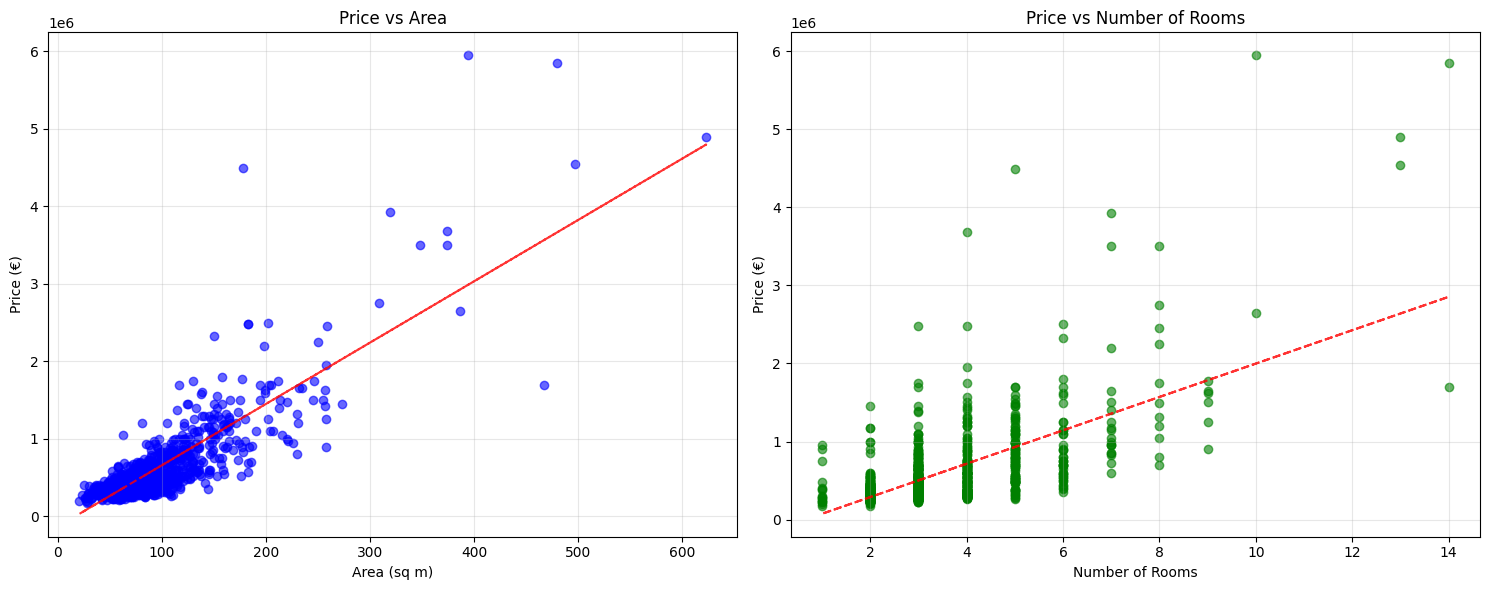

In [33]:
# Scatter plots and pair plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price vs Area
axes[0].scatter(df["Area"], df["Price"], alpha=0.6, color="blue")
axes[0].set_xlabel("Area (sq m)")
axes[0].set_ylabel("Price (€)")
axes[0].set_title("Price vs Area")
axes[0].grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(df["Area"], df["Price"], 1)
p = np.poly1d(z)
axes[0].plot(df["Area"], p(df["Area"]), "r--", alpha=0.8)

# Price vs Rooms
axes[1].scatter(df["Room"], df["Price"], alpha=0.6, color="green")
axes[1].set_xlabel("Number of Rooms")
axes[1].set_ylabel("Price (€)")
axes[1].set_title("Price vs Number of Rooms")
axes[1].grid(True, alpha=0.3)

# Add trend line
z2 = np.polyfit(df["Room"], df["Price"], 1)
p2 = np.poly1d(z2)
axes[1].plot(df["Room"], p2(df["Room"]), "r--", alpha=0.8)

plt.tight_layout()
plt.show()

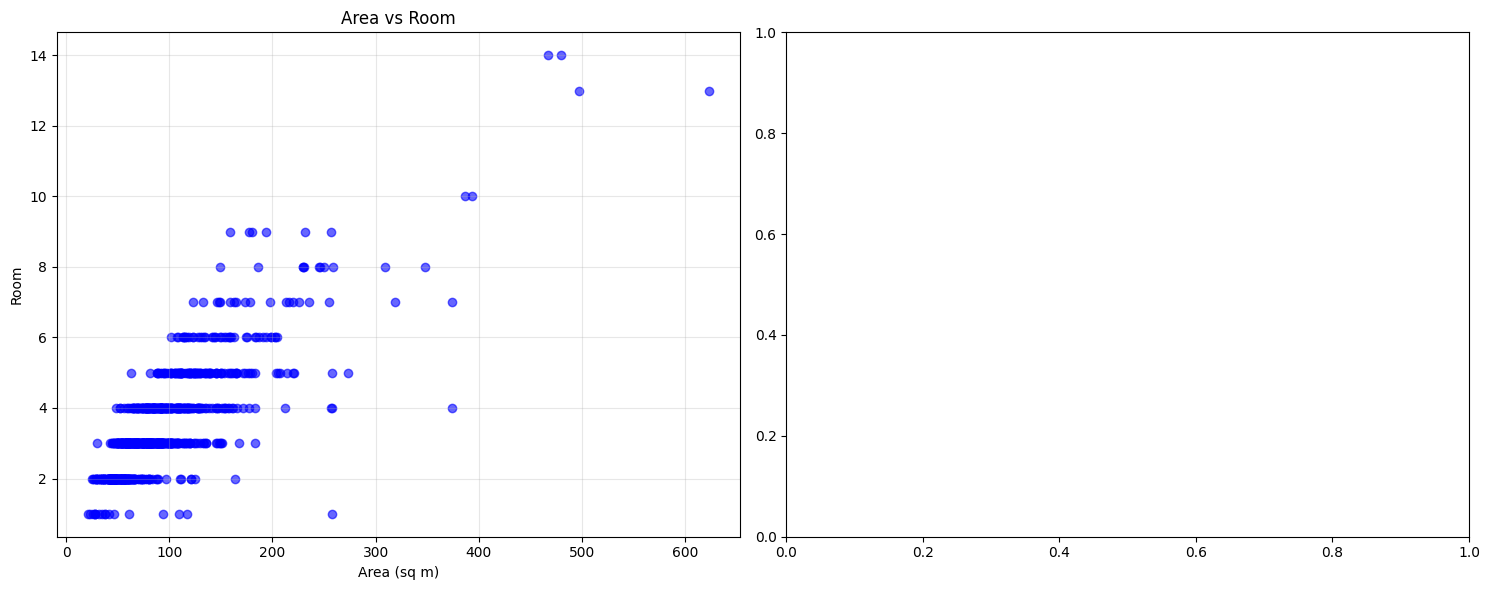

In [43]:
# Scatter plots and pair plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Price vs Area
axes[0].scatter(df["Area"], df["Room"], alpha=0.6, color="blue")
axes[0].set_xlabel("Area (sq m)")
axes[0].set_ylabel("Room")
axes[0].set_title("Area vs Room")
axes[0].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

there is a strong correlation between rooms and area which is logical but not good

### Categorical vs Numerical Analysis

            mean     median         std  count
Room                                          
1      394529.41   295000.0   241565.76     17
2      383479.06   350000.0   166376.29    191
3      512416.40   450000.0   251758.65    330
4      609845.09   500000.0   401181.72    201
5      845076.40   750000.0   518335.89     97
6      919928.57   750000.0   506695.96     42
7     1394736.84  1050000.0   899211.81     19
8     1751636.36  1499000.0   885989.42     11
9     1450000.00  1562500.0   322877.69      6
10    4300000.00  4300000.0  2333452.38      2
13    4725000.00  4725000.0   247487.37      2
14    3772500.00  3772500.0  2938028.68      2


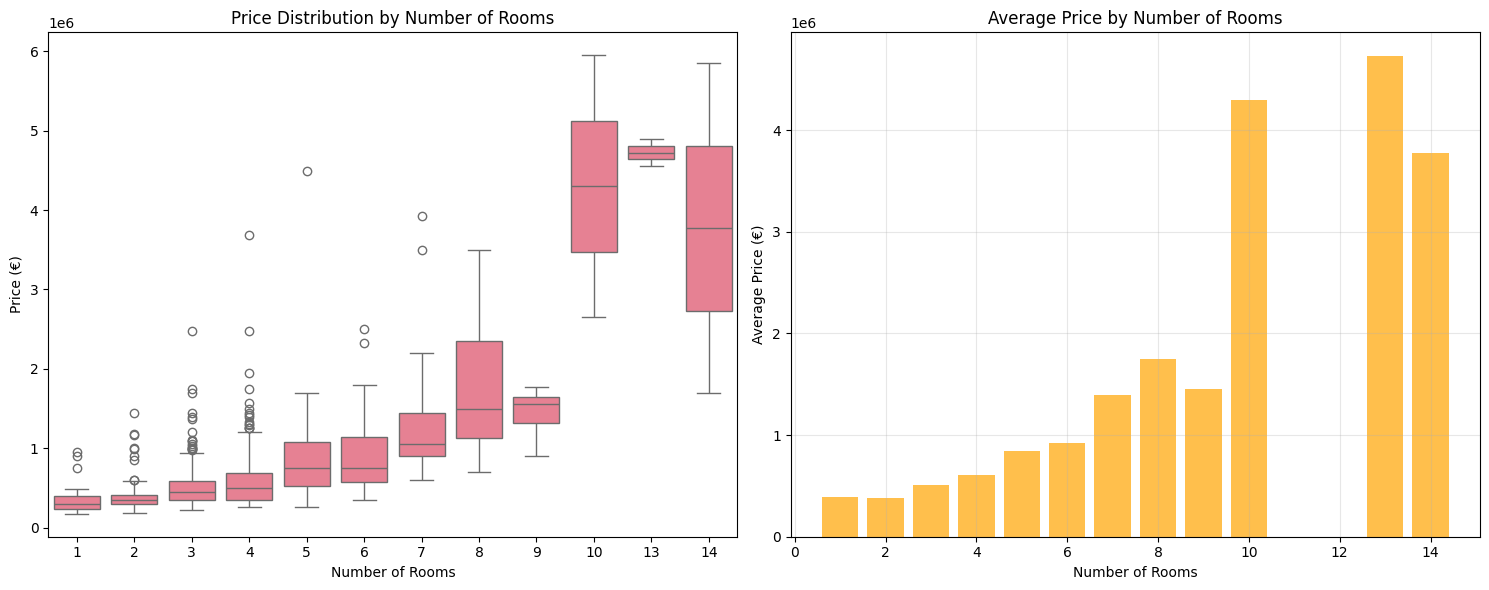

In [34]:
price_by_rooms = df.groupby("Room")["Price"].agg(["mean", "median", "std", "count"]).round(2)
print(price_by_rooms)

# Visualize price by room count
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Box plot
sns.boxplot(data=df, x="Room", y="Price", ax=axes[0])
axes[0].set_title("Price Distribution by Number of Rooms")
axes[0].set_xlabel("Number of Rooms")
axes[0].set_ylabel("Price (€)")

# Bar plot of mean prices
room_means = df.groupby("Room")["Price"].mean()
axes[1].bar(room_means.index, room_means.values, color="orange", alpha=0.7)
axes[1].set_title("Average Price by Number of Rooms")
axes[1].set_xlabel("Number of Rooms")
axes[1].set_ylabel("Average Price (€)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Key Insights and Summary

Based on the EDA of the Amsterdam housing dataset from August 2021, several key patterns exist regarding the relationship between property characteristics and pricing. The dataset contains minimal missing values, with only 4 rows requiring removal due to missing price information, ensuring data integrity for analysis. The numerical variables (Price, Area, Room) all exhibit right-skewed distributions with the presence of outliers, indicating that while most properties fall within typical ranges, there are luxury properties that command significantly higher prices and occupy larger spaces.
